Set directories and parameters

In [1]:
# beta_dir = "example_data/example_beta_files/"
beta_dir = "/Users/ivandevert/projects/spectral_falloff_ratio/data/beta_files/"
catalog_dir = "/Users/ivandevert/projects/ridgecrest2019_prev/res/event_catalog.txt"
delsig_catalog_dir = "/Users/ivandevert/projects/spectral_falloff_ratio/data/other/shearer_2022_full_delsig_local_ecs.csv"

stn_req = 2
nrecords_min = 1
dist_bin_width = 10

dist_max = 1000

xsec_dmax = 1500


In [2]:
# %matplotlib ipympl


import numpy as np
import scipy
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
import struct
import math
import time

import stressdrop_file_IO as sdio
import seismo_functions as sf
import mapping_tools as mt
import importlib
importlib.reload(sdio)
import obspy

from scipy import sparse
import utm
import copy 

import ipywidgets as widgets
from ipywidgets import interactive

from shapely.geometry import Point, MultiPoint
from shapely.geometry.polygon import Polygon


Define some functions

In [3]:
def read_beta_files(beta_dir):
    
    beta_files = [el for el in os.listdir(beta_dir) if el.endswith('.beta')]
    beta_files.sort()
    nfiles = len(beta_files)

    df = pd.DataFrame({
        "stname": pd.arrays.SparseArray(dtype="str", data=[]), 
        "slat": pd.arrays.SparseArray(dtype="float", data=[]), 
        "slon": pd.arrays.SparseArray(dtype="float", data=[]), 
        "selev": pd.arrays.SparseArray(dtype="float", data=[]), 

        "event_id": pd.arrays.SparseArray(dtype="object", data=[]), 
        "qmag": pd.arrays.SparseArray(dtype="object", data=[]), 
        "qlat": pd.arrays.SparseArray(dtype="object", data=[]), 
        "qlon": pd.arrays.SparseArray(dtype="object", data=[]), 
        "qdep": pd.arrays.SparseArray(dtype="object", data=[]), 
        "beta": pd.arrays.SparseArray(dtype="object", data=[]), 
        "stn": pd.arrays.SparseArray(dtype="object", data=[]), 
        "deldist": pd.arrays.SparseArray(dtype="object", data=[]), 
    })

    for i in range(nfiles):
        filepath = beta_dir + beta_files[i]

        f = open(filepath, 'rb')
        f.seek(0, 2)
        file_size = f.tell()
        f.seek(0, 0)

        junk = struct.unpack('i', f.read(4))[0]
        FMT_VERSION = struct.unpack('i', f.read(4))[0]

        if FMT_VERSION == 0:
            stname = f.read(20).decode('UTF-8')
            slat = struct.unpack('f', f.read(4))[0]
            slon = struct.unpack('f', f.read(4))[0]
            selev = struct.unpack('f', f.read(4))[0]
            beta_method = f.read(30).decode('UTF-8')
            stn_method = f.read(30).decode('UTF-8')
            low_f_band = (struct.unpack('f', f.read(4))[0], 
                          struct.unpack('f', f.read(4))[0])
            high_f_band = (struct.unpack('f', f.read(4))[0],
                           struct.unpack('f', f.read(4))[0])
            nevents = struct.unpack('i', f.read(4))[0]

            evids = np.zeros(nevents, dtype='<U20')
            qmag = np.zeros(nevents, dtype=float)
            qlat = np.zeros_like(qmag)
            qlon = np.zeros_like(qmag)
            qdep = np.zeros_like(qmag)
            beta = np.zeros_like(qmag)
            stn = np.zeros_like(qmag)
            deldist = np.zeros_like(qmag)
            for j in range(nevents):
                junk1 = struct.unpack('i', f.read(4))[0]
                junk2 = struct.unpack('i', f.read(4))[0]
                # print(junk1, junk2)
                evids[j] = f.read(20).decode('UTF-8').strip('\x01\x00')
                junk = struct.unpack('i', f.read(4))[0]
                qmag[j] = struct.unpack('f', f.read(4))[0]
                qlat[j] = struct.unpack('f', f.read(4))[0]
                qlon[j] = struct.unpack('f', f.read(4))[0]
                qdep[j] = struct.unpack('f', f.read(4))[0]
                beta[j] = struct.unpack('f', f.read(4))[0]
                stn[j] = struct.unpack('f', f.read(4))[0]
                deldist[j] = struct.unpack('f', f.read(4))[0]
            df.loc[len(df)] = [stname, slat, slon, selev, evids, qmag, qlat, qlon, qdep, beta, stn, deldist]
    return df


def read_betatxt_files(filedir, ):

    df = pd.DataFrame({
        "stname": pd.arrays.SparseArray(dtype="str", data=[]), 
        "slat": pd.arrays.SparseArray(dtype="float", data=[]), 
        "slon": pd.arrays.SparseArray(dtype="float", data=[]), 
        "selev": pd.arrays.SparseArray(dtype="float", data=[]), 

        "event_id": pd.arrays.SparseArray(dtype="object", data=[]), 
        "qmag": pd.arrays.SparseArray(dtype="object", data=[]), 
        "beta": pd.arrays.SparseArray(dtype="object", data=[]), 
        "stn": pd.arrays.SparseArray(dtype="object", data=[]), 
        "deldist": pd.arrays.SparseArray(dtype="object", data=[]), 
    })

    beta_files = [el for el in os.listdir(filedir) if el.endswith('.betatxt')]

    nfiles = len(beta_files)

    for j in range(nfiles):
        filepath = filedir + beta_files[j]

        low_f_band = np.zeros(2, dtype=float)
        high_f_band = np.zeros(2, dtype=float)

        with open(filepath, 'r') as fp:
            line = fp.readline().strip()

        stname, slat, slon, selev, beta_method, stn_method, low_f_band[0], \
        low_f_band[1], high_f_band[0], high_f_band[1], nevents \
        = line.split("  ")

        # print(line)

        column_names = ['event_id', 'qmag', 'beta', 'stn', 'deldist']
        data = pd.read_csv(filepath, sep='\\s+', skiprows=1, 
            names=column_names)
        event_id = data['event_id'].values
        qmag = data['qmag'].values
        beta = data['beta'].values
        stn = data['stn'].values
        deldist = data['deldist'].values
        df.loc[len(df)] = [stname, slat, slon, selev, event_id, qmag, beta, stn, deldist]

        # print(data)
    df['slat'] = df['slat'].astype(float)
    df['slon'] = df['slon'].astype(float)
    df['selev'] = df['selev'].astype(float)


    return df

def filter_stn(row, stn_req, dependents):
    # print(row)
    keep_bool = np.array(row['stn'])>=stn_req

    for el in dependents:
        row[el] = row[el][keep_bool]
    return row
    

def get_colormap(d, cmap='coolwarm_r', method='percentile', **kwargs):

    d = d.astype(float)
    n = len(d)
    
    if method=='percentile':
        assert 'percentiles' in kwargs.keys(), "percentiles must be in kwargs"

        pct = kwargs['percentiles']

        d_sort = np.sort(d)

        cmap = plt.get_cmap(cmap)
        bounds = np.linspace(d_sort[int(pct[0]*n)], d_sort[int(pct[1]*n)], 7)
        norm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='both')

        smap = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    if method=='mediancenter':

        center = np.median(d)
        if 'percentiles' in kwargs.keys():
            pct = kwargs['percentiles']
        else:
            pct = [0.05, 0.95]
        
        d_sort = np.sort(d)

        center_dists = np.array(center - d_sort[int(pct[0]*n)], 
                                d_sort[int(pct[1]*n)] - center)
        dist = np.mean(center_dists)

        cmap = plt.get_cmap(cmap)
        bounds = np.linspace(center-dist, center+dist, 7)
        norm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='both')

        smap = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

    if method=='logmediancenter':
        logd = np.log10(d)
        logcenter = np.median(logd)
        if 'percentiles' in kwargs.keys():
            pct = kwargs['percentiles']
        else:
            pct = [0.05, 0.95]
        
        logd_sort = np.sort(logd)

        center_dists = np.array(logcenter - logd_sort[int(pct[0]*n)], 
                                logd_sort[int(pct[1]*n)] - logcenter)
        dist = np.mean(center_dists)

        cmap = plt.get_cmap(cmap)
        bounds = np.logspace(logcenter-dist, logcenter+dist, 7)
        norm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='both')

        smap = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

    return cmap, smap, norm



def p_norm(v, p):
    """Return the p-norm of a vector v (see ref. [2])

    Args:
        v (np.ndarray): array to calculate p-norm of
        p (int): p for p-norm

    Returns:
        float: p-norm of v
    """
    return np.power(np.sum(np.power(np.abs(v), p)), 1/p)

def model_p_norm(m, model_function, t, d, p):
    """Intermediate function for calculating the p-norm.

    Args:
        m (array-like): array of model parameters
        model_function (function): callable function
        t (np.ndarray): independent variable
        d (np.ndarray): data array
        p (int): p for p-norm

    Returns:
        float: p-norm of the residual (expected - observed) array
    """
    y = model_function(m, t)
    return p_norm(y - d, p)

def fit_p_norm(x, d, model, m0, p):
    """Find a fit to a model using scipy.optimize.minimize()

    Args:
        x (np.ndarray): independent variable
        d (np.ndarray): observations
        model (function): callable function, with inputs m (model 
            params) and x
        m0 (array-like): starting values for model parameters
        p (int): integer for choosing p-norm (1: L1-norm, 2: L2-norm, 
            etc.)

    Returns:
        np.ndarray: Best-fit model parameters
    """
    from scipy.optimize import minimize
    res = minimize(model_p_norm, m0, args=(model, x, d, p))
    return res.x

def line_model(m, x):
    """Slope-intercept form of a line.

    Args:
        m (array-like): (slope, intercept)
        x (np.ndarray): independent variable

    Returns:
        np.ndarray: y values on line
    """
    return m[0] * x + m[1]

def fit_line_p_norm(x, y, p):
    """Fit a simple line to x, y data using the p-norm.

    Args:
        x (np.ndarray): x values of data
        y (np.ndarray): y values of data
        p (np.ndarray): which norm to use to calculate the line 
            parameters. Least-squares when p==2.

    Returns:
        np.ndarray: (slope, intercept) of best-fit line.
    """
    m0 = np.polyfit(x, y, 1)
    return fit_p_norm(x, y, line_model, m0, p)



Load earthquake catalogs (for locations) and previous results (for stress drop)

In [4]:
# cat = pd.read_csv(catalog_dir, sep='\\s+')
delsig_cat_names = ["event_id", 'qyr', 'qmon', 'qday', 'qhr', 'qmn', 'qsc', "qmag", 'qlat', 'qlon', 'qdep', 'ntraces', 'ncal', 'fc', 'misfit', 'delsig', 'mest', 'mw_est', 'm0', 'beta']
delsig_cat = pd.read_csv(delsig_catalog_dir, names=delsig_cat_names)
delsig_cat = delsig_cat[['event_id', 'delsig']]

# initialize distance bin array
dist_bins = np.arange(0, dist_max+1, dist_bin_width)

A =     np.array([4.33E5, 3.974E6])
Ap =    np.array([4.665E5, 3.938E6])

B =     np.array([4.40E5, 3.9343E6])
Bp =    np.array([4.60E5, 3.9543E6])

Load data, index events and stations, and filter out bad results. This is to setup for the inverse problem.

In [6]:

# These are columns that are station-dependent, event-dependent, and 
# both-dependent. pandas pivot_table might be useful here
st_dep = ['stname', 'slat', 'slon', 'selev']
ev_dep = ['event_id', 'qmag', "qlon", "qlat", "qdep"]
dependents = ['beta', 'stn', 'deldist']

# read betatxt files into df_sta DataFrame
# df_sta = read_betatxt_files(beta_dir)
df_sta = read_beta_files(beta_dir)
nstations_initial = len(df_sta)

# explode!
df = df_sta.explode(ev_dep + dependents)
df['event_id'] = df['event_id'].astype(int)
df['qmag'] = df['qmag'].astype(float)
df['qlat'] = df['qlat'].astype(float)
df['qlon'] = df['qlon'].astype(float)
df['qdep'] = df['qdep'].astype(float)
df['beta'] = df['beta'].astype(float)
df['stn'] = df['stn'].astype(float)
df['deldist'] = df['deldist'].astype(float)
nrecords_initial = len(df)

# get number of initial events
nevents_initial = len(df['event_id'].unique())
print(f"{nevents_initial} events, recorded by {nstations_initial} stations, resulting in {nrecords_initial} records loaded.")

# bin values by distance, first removing distant records
df = df[df['deldist']<=dist_max]
print(f"{nrecords_initial-len(df)} distant (>{dist_max:.1f} km) records removed")
df['distind'] = np.searchsorted(dist_bins, df['deldist'].values.astype(float)) - 1
dependents += ['distind']

# filter out bad STN records
df = df[df['stn']>=stn_req]
df.reset_index(drop=True, inplace=True)
print(f"{len(df)} records ({len(df)/nrecords_initial*100:.1f}%) passed STN ratio requirement of {stn_req:.1f}")

# make sure each earthquake has enough remaining records
df_ev = df.groupby(ev_dep, as_index=False)[st_dep+dependents].agg(list)
df_ev = df_ev[df_ev['stname'].map(len) >= nrecords_min].reset_index(drop=True)
print(f"{int(nevents_initial-len(df_ev))} events removed due to not enough records (needs >= {nrecords_min})")

# merge eq locations and rename the columns
# df_ev = pd.merge(df_ev, cat, how='inner', on='event_id')
# df_ev = df_ev.rename({'longitude':'qlon', 'latitude':'qlat', 'depth':'qdep'}, axis=1)
# ev_dep += ["qlon", "qlat", "qdep"]

df_ev['easting'], df_ev['northing'], zn, zl = utm.from_latlon(
    df_ev['qlat'].values, 
    df_ev['qlon'].values
    )
ev_dep += ['easting', 'northing']

df_ev.reset_index(drop=True, inplace=True)

# add an event index value 'evind' and explode back into df
df_ev['evind'] = df_ev.index.values.astype(int)
ev_dep += ['evind']
df = df_ev.explode(st_dep + dependents)
df.reset_index(drop=True, inplace=True)

# group by station to add index
df_sta = df.groupby(st_dep, as_index=False)[ev_dep+dependents].agg(list)
df_sta['stind'] = df_sta.index.values.astype(int)
st_dep += ['stind']

# explode!
df = df_sta.explode(ev_dep + dependents)
df.reset_index(drop=True, inplace=True)

# group by event
df_ev = df.groupby(ev_dep, as_index=False)[st_dep+dependents].agg(list)

nevents = len(df_ev)
nstations = len(df_sta)
ndata = len(df)

# truncate dist_bins at maximum distance
dist_bins = dist_bins[:np.max(df['distind'])+2]

print("-------------")
print("Final counts:")
print("-------------")
print(f"{nevents} events")
print(f"{nstations} stations")
print(f"{ndata} records")


12942 events, recorded by 529 stations, resulting in 3171003 records loaded.
0 distant (>1000.0 km) records removed
1375622 records (43.4%) passed STN ratio requirement of 2.0
3 events removed due to not enough records (needs >= 1)
-------------
Final counts:
-------------
12939 events
461 stations
1375622 records


Make some checks

In [7]:
# number of events shuold equal number of unique evinds
assert len(df_ev['evind'])==len(df['evind'].unique())

# number of stations shuold equal number of unique stinds
assert len(df_sta['stind'])==len(df['stind'].unique())

A_len = np.sqrt(np.sum(np.power(Ap - A, 2)))
B_len = np.sqrt(np.sum(np.power(Bp - B, 2)))

A_ratio = A_len / (A_len + B_len)
B_ratio = B_len / (A_len + B_len)

gridspec_kw = {"width_ratios": [A_ratio, B_ratio]}


# boxes

# define 2 boxes
B1 = (
    (4.5366E5, 3.94991E6),
    (4.5935E5, 3.94928E6),
    (4.6312E5, 3.94269E6),
    (4.5693E5, 3.93928E6)
    )
z1 = (0, 4)

B2 = (
    (4.4154E5, 3.96037E6),
    (4.4581E5, 3.96317E6),
    (4.5311E5, 3.95558E6),
    (4.4824E5, 3.95248E6)
    )
z2 = (0, 12)


xyz = df_ev[['easting', 'northing', 'qdep']].values
pts = [Point(xyz[i,:2]) for i in range(len(xyz))]

B1poly = Polygon(B1)
B2poly = Polygon(B2)

in_dep1 = np.logical_and(xyz[:,2]>=z1[0], xyz[:,2]<=z1[1])
in_dep2 = np.logical_and(xyz[:,2]>=z2[0], xyz[:,2]<=z2[1])


df_ev['in_B1'] = np.logical_and(B1poly.contains(pts), in_dep1)
df_ev['in_B2'] = np.logical_and(B2poly.contains(pts), in_dep2)


Compare to Shearer et al. 2022 delsigs

In [8]:
xlim = [-1.7, 0.7]
ylim = [1E-1, 1E4]


delsig_df = pd.merge(delsig_cat, df_ev, how='inner', on='event_id')
# delsig_df = delsig_df[delsig_df['qmag'] <= 5.0]

cmap = plt.cm.jet 
bounds = np.arange(1, 6)
norm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='max')


avg_B1_delsig = np.median(delsig_df['delsig'][delsig_df['in_B1']==True])
avg_B2_delsig = np.median(delsig_df['delsig'][delsig_df['in_B2']==True])

print(f"Average delsig in box B1: {avg_B1_delsig:.2f} MPa")
print(f"Average delsig in box B2: {avg_B2_delsig:.2f} MPa")



Average delsig in box B1: 6.37 MPa
Average delsig in box B2: 13.90 MPa


In [9]:
def plot_poly(poly, ax):
    poly = np.array(poly)
    n = len(poly)
    ax.plot(poly[:,0], poly[:,1], c='k')
    ax.plot([poly[-1, 0], poly[0, 0]], [poly[-1, 1], poly[0, 1]], c='k')

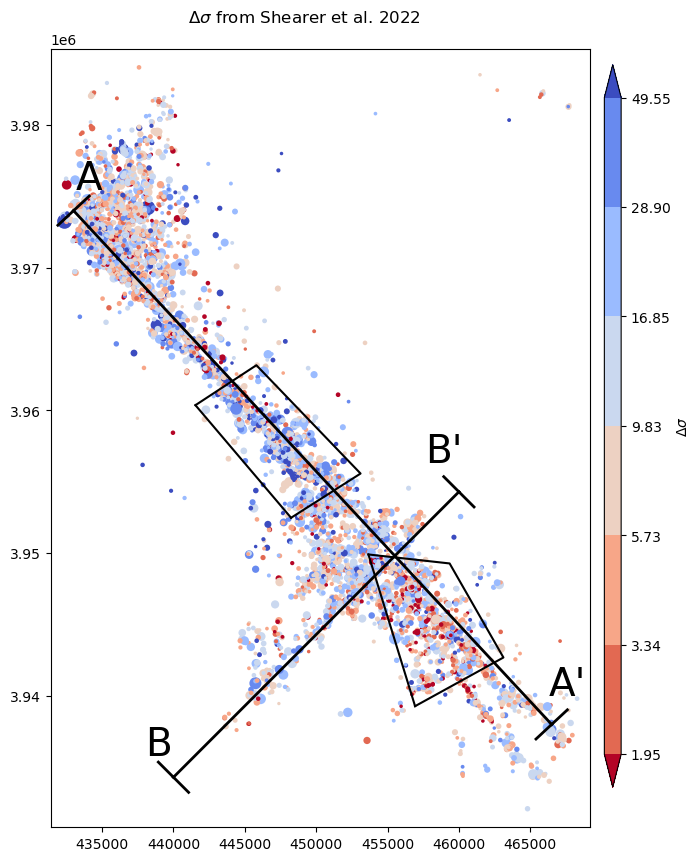

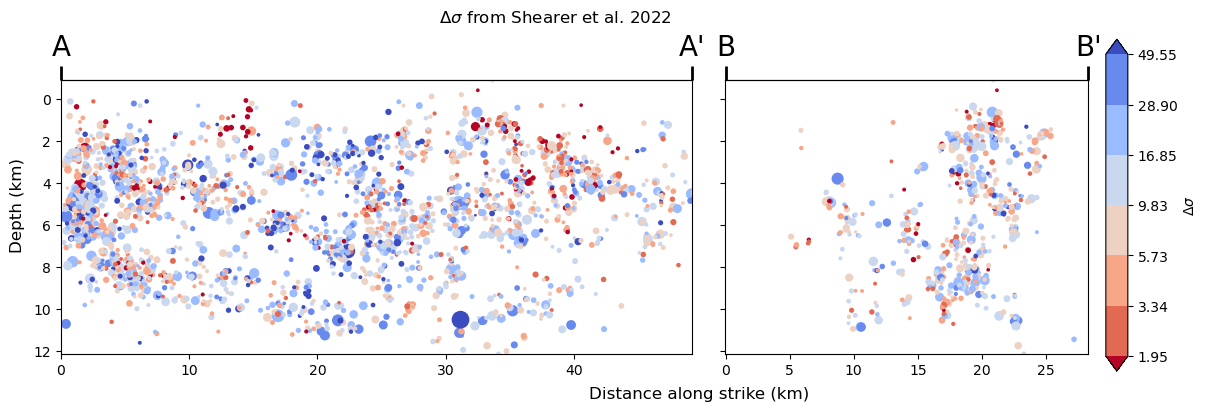

In [10]:






df2 = delsig_df
# df2 = df_ev[np.logical_and(df_ev['qmag']>=1.6, df_ev['qmag']<1.8)]
# df2 = df_ev[df_ev['qdep']<=1.0]
# df2 = df_ev

dataname = 'delsig'
datatitle = r"$\Delta\sigma$"

# cmap, smap, cnorm = get_colormap(df2[dataname].values, percentiles=[0.1, 0.9])
cmap, smap, cnorm = get_colormap(df2[dataname].values, method='logmediancenter')

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 8.5),
    layout='constrained')
mapout = mt.plot_map(
    df2,
    ax=ax,
    zoom=1.05,
    cname=dataname,
    cnorm=cnorm,
    smap=smap,
    distinguish_clipped=False,
    bgcolor=(1,1,1),

)

mt.plot_xsection_line(A, Ap, ax, labels=["A", "A'"], linewidth=2, 
    exact_tick_length=xsec_dmax)
mt.plot_xsection_line(B, Bp, ax, labels=["B", "B'"], linewidth=2, 
    exact_tick_length=xsec_dmax)

cb_ax = fig.add_axes([1.0,.080,.028,.85])
cbar = plt.colorbar(smap, fraction=0.0405, pad=0.02, aspect=35, 
    cax=cb_ax, extend='both')
smap.set_clim([cnorm.vmin, cnorm.vmax])

cbar.ax.set_ylabel(datatitle)
fig.suptitle(datatitle + " from Shearer et al. 2022")

plot_poly(B1, ax)
plot_poly(B2, ax)


fig, [ax1, ax2] = plt.subplots(nrows=1, ncols=2, figsize=(11, 4),
    sharey='all', sharex='col', gridspec_kw=gridspec_kw, layout='constrained')


importlib.reload(mt)
xsecoutA = mt.plot_xsection(
    df2, 
    p1 = A, 
    p2 = Ap, 
    max_dist = xsec_dmax,
    ax=ax1, 
    zname='qdep', 
    map_output=mapout,
    xsecunits='line',
    xy_scale=0.001,
    z_scale=1,
    # big_events=EV,
    bgcolor=(1,1,1),
    cname=dataname,
    )

xsecoutB = mt.plot_xsection(
    df2, 
    p1 = B, 
    p2 = Bp, 
    max_dist = xsec_dmax,
    ax=ax2, 
    zname='qdep', 
    map_output=mapout,
    xsecunits='line',
    xy_scale=0.001,
    z_scale=1,
    # big_events=EV,
    bgcolor=(1,1,1),
    cname=dataname,
    line_name="B"
    )


fig.supylabel("Depth (km)")
fig.supxlabel("Distance along strike (km)", x=0.63)
fig.suptitle(datatitle + " from Shearer et al. 2022")

# colorbar
cb_ax = fig.add_axes([1.0,.085,.02,.83])
cbar = plt.colorbar(smap, fraction=0.0405, pad=0.02, aspect=35, 
    cax=cb_ax, extend='both')
# smap.set_clim(clim)
# cbar.ax.set_yticks(cticks)
# cbar.ax.set_yticklabels(clabels)
cbar.ax.set_ylabel(datatitle)

# fig.canvas.draw_idle()

plt.show()




In [11]:
df_1 = df_ev[df_ev['in_B1']==True].reset_index(drop=True, inplace=False)
df_2 = df_ev[df_ev['in_B2']==True].reset_index(drop=True, inplace=False)

df_1.drop(labels=['in_B1', 'in_B2'], axis='columns')
df_2.drop(labels=['in_B1', 'in_B2'], axis='columns')

df_1 = df_1.explode(st_dep + dependents).reset_index(drop=True, inplace=False)
st_1 = df_1.groupby(st_dep, as_index=False)[ev_dep+dependents].agg(list)

df_2 = df_2.explode(st_dep + dependents).reset_index(drop=True, inplace=False)
st_2 = df_2.groupby(st_dep, as_index=False)[ev_dep+dependents].agg(list)

In [13]:
# xlim = [1, 5]
# X = np.array([0, 5])

def avg_dist(row):
    return np.mean(row['deldist'])


def get_slope(row):
    if len(row['qmag']) > 1:
        return fit_line_p_norm(np.array(row['qmag']), np.log10(row['beta']), 1)[0]
    else:
        return np.nan



st_1['beta_slope'] = st_1.apply(get_slope, axis=1)
st_2['beta_slope'] = st_2.apply(get_slope, axis=1)

st_1['avg_dist'] = st_1.apply(avg_dist, axis=1)
st_2['avg_dist'] = st_2.apply(avg_dist, axis=1)



In [ ]:
def fit_line_emcee(x, y, nwalkers=16):

    # first, fit the line with a 2 norm
    M = fit_line_p_norm(qmag, np.log10(beta), 2)


    # perturb solution
    ndim = len(M)
    pos = M + 1e-4 * np.random.randn(nwalkers, ndim)

    sampler = emcee.EnsembleSampler(
        nwalkers, ndim, log_probability, args=(x, y, yerr)
    )

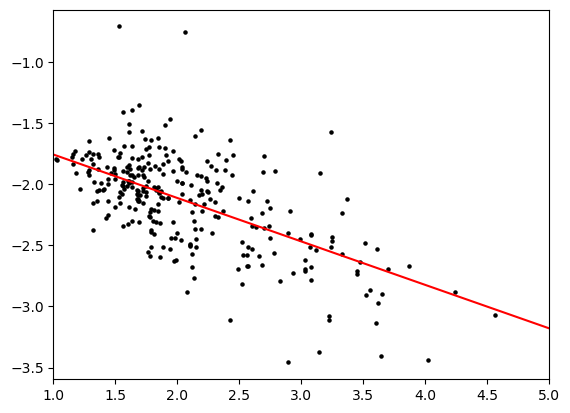

In [35]:
xlim = [1, 5]
X = np.array([0, 5])
slope1 = np.zeros(len(st_1)) - 99.0
for i in range(4):
    qmag = np.array(st_1.at[i, 'qmag'])
    beta = np.array(st_1.at[i, 'beta'])

    if len(qmag) >10:

        M = fit_line_p_norm(qmag, np.log10(beta), 1)
        slope1[i] = M[0]
        plt.figure()
        plt.scatter(qmag, np.log10(beta), c='k', s=5)
        plt.xlim(xlim)
        # plt.yscale('log')

        plt.plot(X, M[0]*X + M[1], c='r')

        plt.show()

# slope2 = np.zeros(len(st_2)) - 99.0
# for i in range(len(st_2)):
#     qmag = np.array(st_2.at[i, 'qmag'])
#     beta = np.array(st_2.at[i, 'beta'])

#     if len(qmag) >1:

#         M = fit_line_p_norm(qmag, np.log10(beta), 1)
#         slope2[i] = M[0]

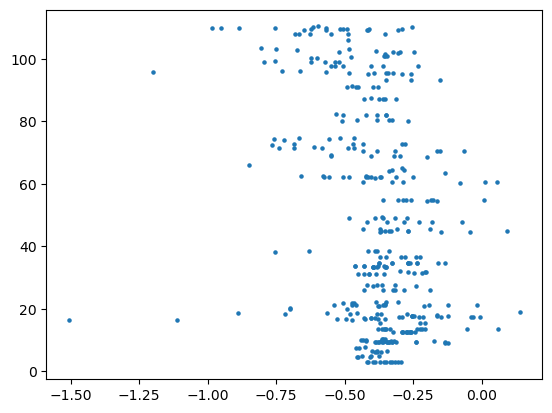

In [15]:
plt.figure()
plt.scatter(np.array(st_1['beta_slope']), np.array(st_1['avg_dist']), s=5)
plt.show()

-0.363290246074554
-0.25566005156820687


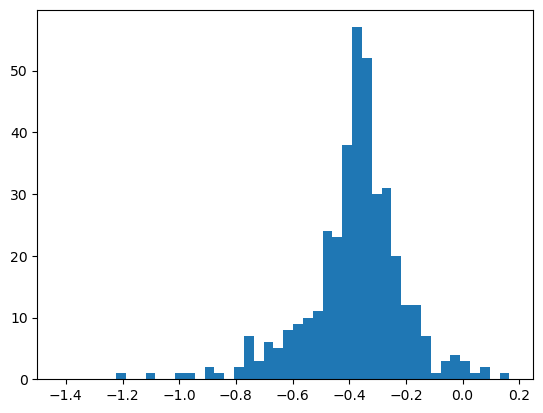

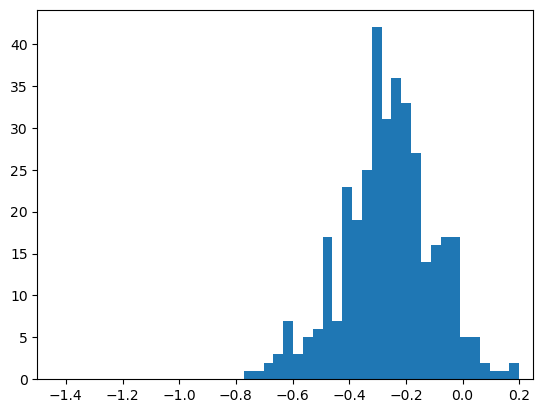

In [16]:
bins = np.linspace(-1.5, 0.2, 50)

print(np.nanmedian(st_1['beta_slope']))
print(np.nanmedian(st_2['beta_slope']))

plt.hist(st_1['beta_slope'], bins=bins)
plt.xlim((-1.5, 0.25))
plt.show()
plt.hist(st_2['beta_slope'], bins=bins)
plt.xlim((-1.5, 0.25))
plt.show()

36.642550452349056
32.22205563100385


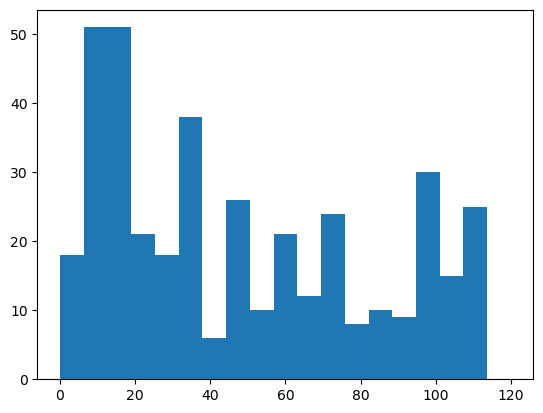

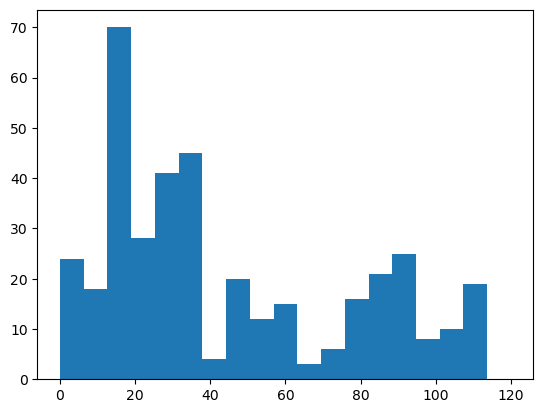

In [17]:
bins = np.linspace(0, 120, 20)

print(np.median(st_1['avg_dist']))
print(np.median(st_2['avg_dist']))

plt.hist(st_1['avg_dist'], bins=bins)
# plt.xlim((-1.5, 0.25))
plt.show()
plt.hist(st_2['avg_dist'], bins=bins)
# plt.xlim((-1.5, 0.25))
plt.show()

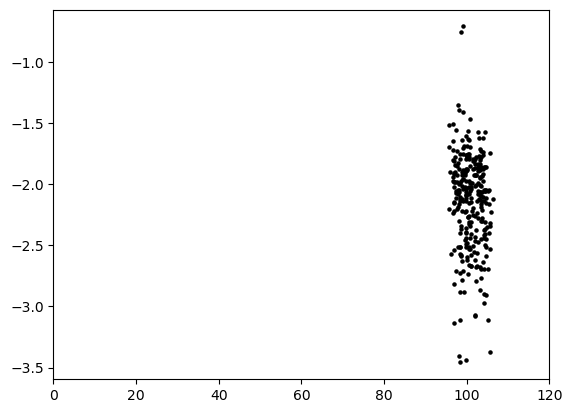

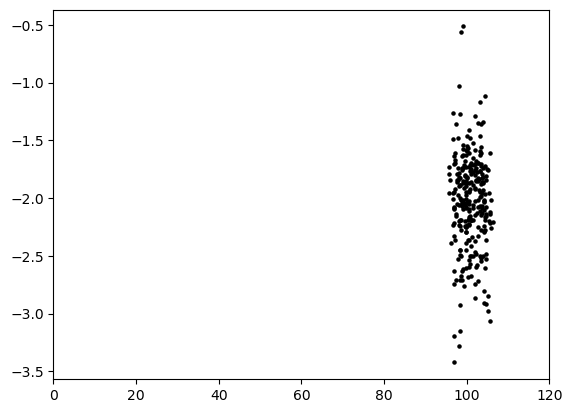

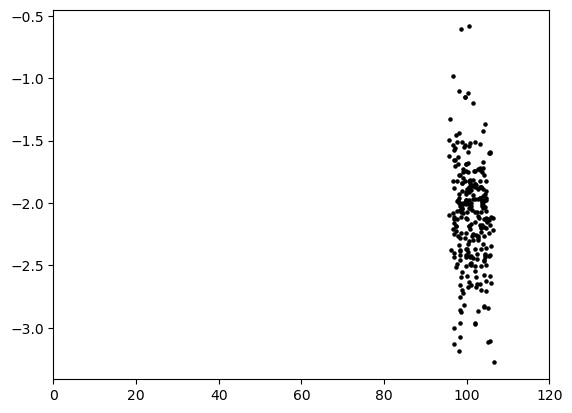

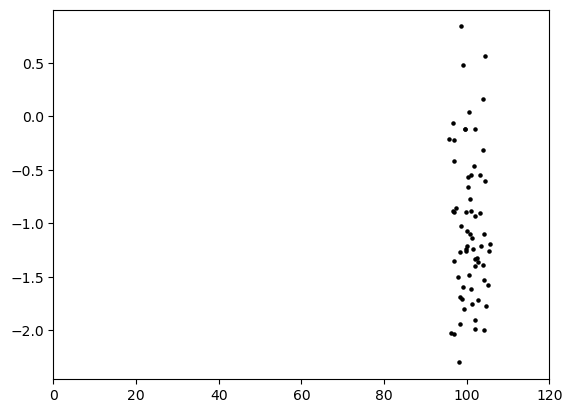

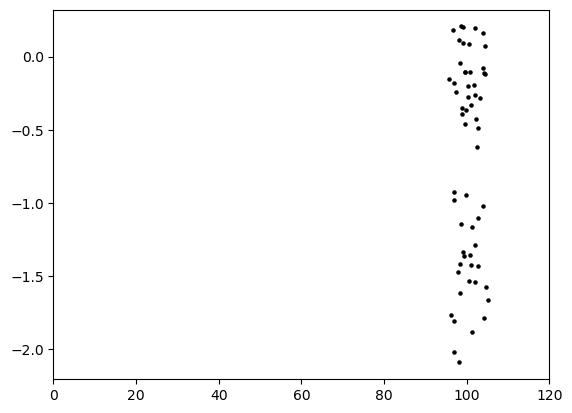

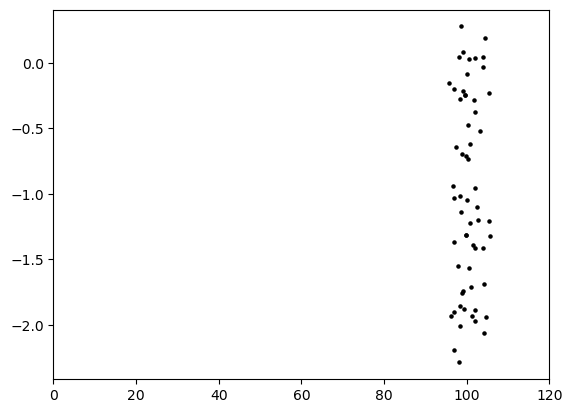

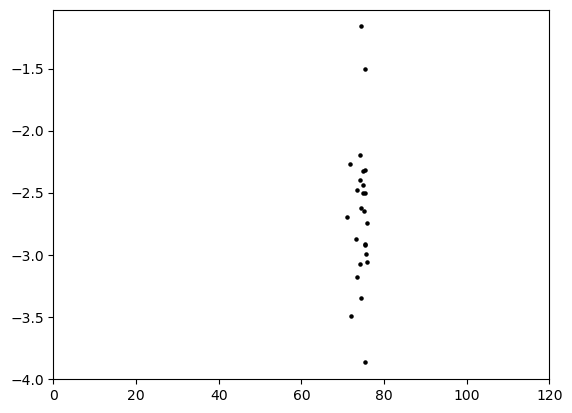

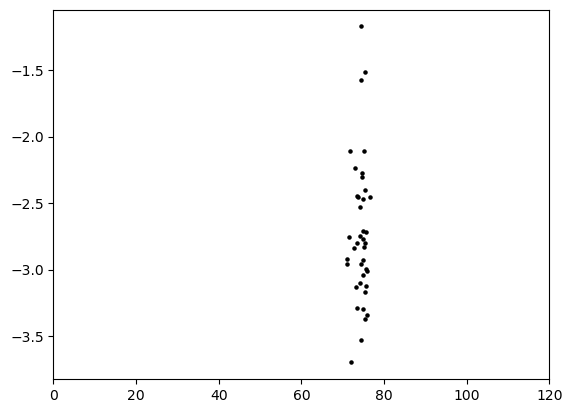

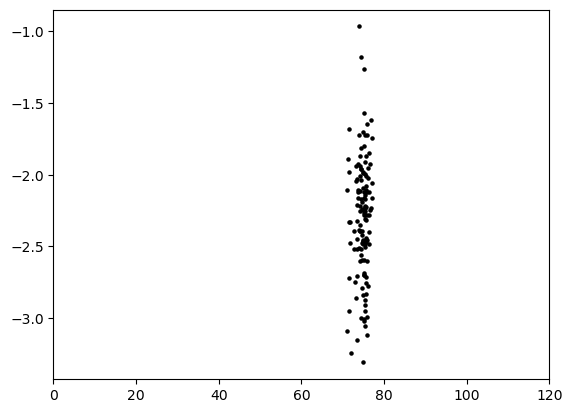

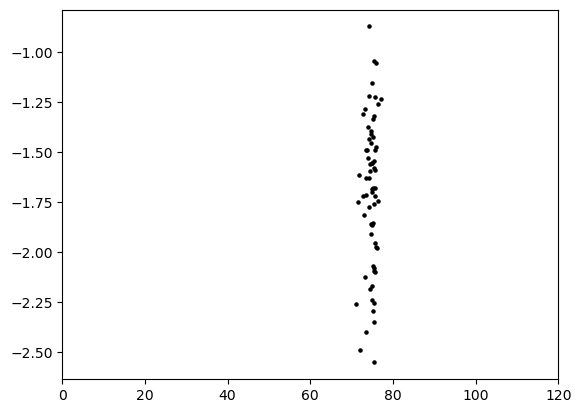

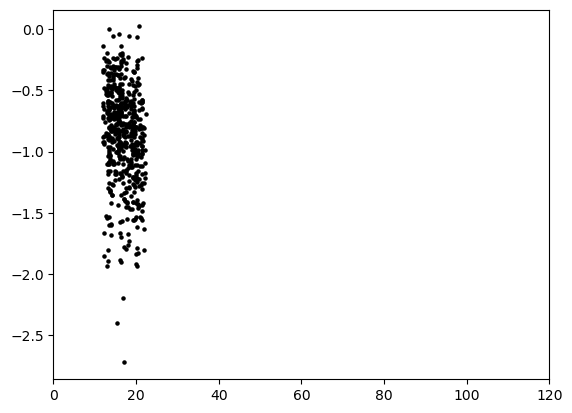

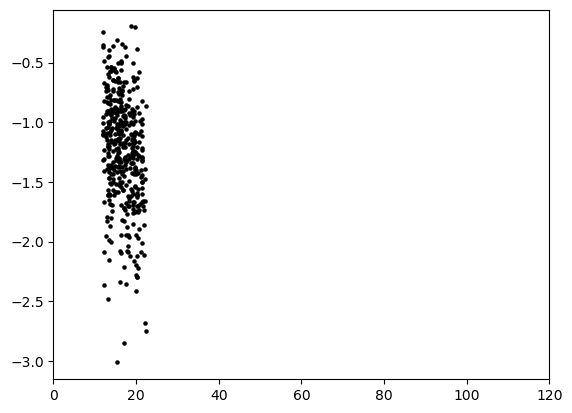

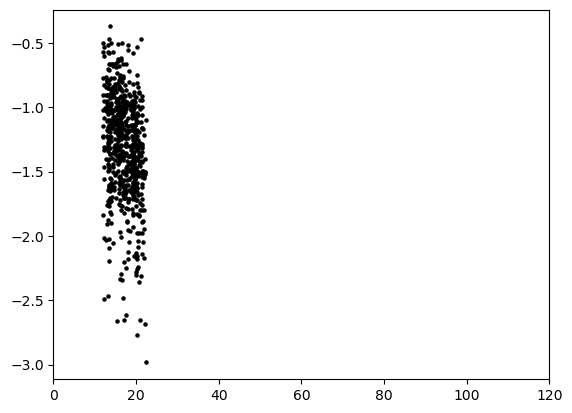

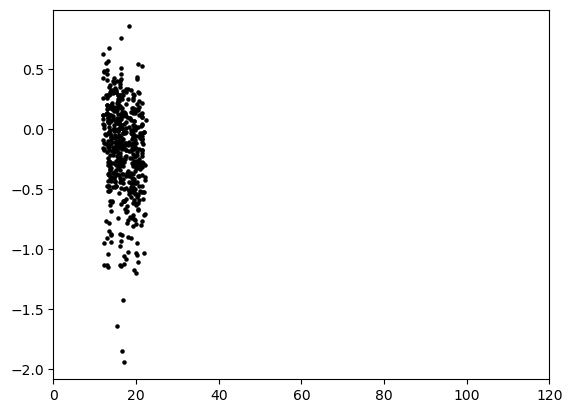

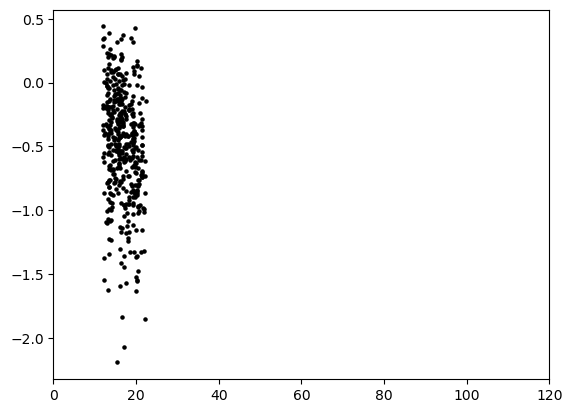

In [18]:
xlim = (0, 120)
for i in range(20):
    dist = np.array(st_1.at[i, 'deldist'])
    beta = np.array(st_1.at[i, 'beta'])

    if len(dist) >10:

        # M = fit_line_p_norm(dist, np.log10(beta), 1)
        # slope1[i] = M[0]
        plt.figure()
        plt.scatter(dist, np.log10(beta), c='k', s=5)
        plt.xlim(xlim)
        # plt.yscale('log')

        # plt.plot(X, M[0]*X + M[1], c='r')

        plt.show()

### emcee testing

You must install the tqdm library to use progress indicators with emcee


Maximum likelihood estimates:
m = -1.003
b = 4.528
f = 0.454


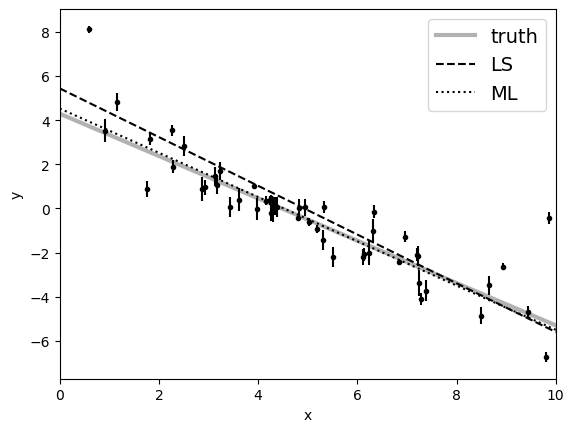

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
import emcee
import corner 
import tqdm



def log_likelihood(theta, x, y, yerr):
    m, b, log_f = theta
    model = m * x + b
    sigma2 = yerr**2 + model**2 * np.exp(2 * log_f)
    return -0.5 * np.sum((y - model) ** 2 / sigma2 + np.log(sigma2))

def log_prior(theta):
    m, b, log_f = theta
    if -5.0 < m < 0.5 and 0.0 < b < 10.0 and -10.0 < log_f < 1.0:
        return 0.0
    return -np.inf

def log_probability(theta, x, y, yerr):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, x, y, yerr)

np.random.seed(123)

# Choose the "true" parameters.
m_true = -0.9594
b_true = 4.294
f_true = 0.534

# Generate some synthetic data from the model.
N = 50
x = np.sort(10 * np.random.rand(N))
yerr = 0.1 + 0.5 * np.random.rand(N)
y = m_true * x + b_true
y += np.abs(f_true * y) * np.random.randn(N)
y += yerr * np.random.randn(N)

from scipy.optimize import minimize

np.random.seed(42)
nll = lambda *args: -log_likelihood(*args)
initial = np.array([m_true, b_true, np.log(f_true)]) + 0.1 * np.random.randn(3)
soln = minimize(nll, initial, args=(x, y, yerr))
m_ml, b_ml, log_f_ml = soln.x

print("Maximum likelihood estimates:")
print("m = {0:.3f}".format(m_ml))
print("b = {0:.3f}".format(b_ml))
print("f = {0:.3f}".format(np.exp(log_f_ml)))

plt.errorbar(x, y, yerr=yerr, fmt=".k", capsize=0)
plt.plot(x0, m_true * x0 + b_true, "k", alpha=0.3, lw=3, label="truth")
plt.plot(x0, np.dot(np.vander(x0, 2), w), "--k", label="LS")
plt.plot(x0, np.dot(np.vander(x0, 2), [m_ml, b_ml]), ":k", label="ML")
plt.legend(fontsize=14)
plt.xlim(0, 10)
plt.xlabel("x")
plt.ylabel("y");



pos = soln.x + 1e-4 * np.random.randn(32, 3)
nwalkers, ndim = pos.shape

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(x, y, yerr)
)
sampler.run_mcmc(pos, 5000, progress=True);